Initial model trained on 15 features selected by sorting for mutual importance in the original feature set, then correcting for correlated features.

Training workflow for the NN classifier:
Gets the already preproccessed, and split data (see fast_preprocess_data in utils for details)
Initializes it into a three layer NN
Trains this model based on some educated guesses on good hyper params and architecture shape.
Varifies that the model has potential and converges.
Tunes hyper pyrameters with optuna (uncomment for rerun takes about 90 min on M5 chip)
Retrains a tuned model based on given best parameters from optuna.
Saves said model weights and parameters to disk for future use to use on the test sample.


In [1]:
import torch
from torch import nn
import sys
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
sys.path.append('../..')  # goes up from NN/ to I_Project/
from Modules.Utils import fast_preprocess_data
from Modules.models import ThreeLayerNN
import optuna

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt







In [2]:
#data prep
X_train, X_val, y_train, y_val = fast_preprocess_data('../../Data/AppML_InitialProject_train.h5', 'p_Truth_isElectron')


# model Architecture
input_size = X_train.shape[1]
first_layer_size = 128
second_layer_size = 64
third_layer_size = 32



# Hyperparameters
lr = 0.001 # learning rate
epochs = 1000
patience = 20 # for early stopping

batch_size = 256  # for DataLoader

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the model, loss function, and optimizer
model_1 = ThreeLayerNN(input_size, first_layer_size, second_layer_size, third_layer_size).to(device)
print("using device:", device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model_1.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)


Dataset loaded from ../../Data/AppML_InitialProject_train.h5 with shape (180000, 140)
Target variable 'p_Truth_isElectron' has 2 unique values and distribution:
p_Truth_isElectron
0    0.79
1    0.21
Name: proportion, dtype: float64
No missing values detected in the dataset.
Dropped 44 highly correlated features
Dropped 44 highly correlated features
using device: mps
using device: mps


In [3]:
# train the model
train_dataset = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
val_loader = DataLoader(val_dataset, batch_size=batch_size)

best_loss = float('inf')
counter = 0
train_losses = []
val_losses = []

for epoch in range(epochs):
    model_1.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_1(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)

    model_1.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_1(X_batch).squeeze()
            val_loss += criterion(outputs, y_batch).item()
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_epoch_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    train_losses.append(avg_epoch_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0
        torch.save(model_1.state_dict(), 'best_model.pth')
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model_1.load_state_dict(torch.load('best_model.pth'))


# Evaluate the model
model_1.eval()
with torch.no_grad():
    y_pred = model_1(torch.tensor(X_val.values, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    y_pred_binary = (y_pred > 0.5).astype(int)
    accuracy = accuracy_score(y_val, y_pred_binary)
    precision = precision_score(y_val, y_pred_binary)
    recall = recall_score(y_val, y_pred_binary)
    f1 = f1_score(y_val, y_pred_binary)
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")


Epoch 1/1000, Train Loss: 0.2389, Val Loss: 0.2028
Epoch 2/1000, Train Loss: 0.1973, Val Loss: 0.1935
Epoch 2/1000, Train Loss: 0.1973, Val Loss: 0.1935
Epoch 3/1000, Train Loss: 0.1900, Val Loss: 0.1905
Epoch 3/1000, Train Loss: 0.1900, Val Loss: 0.1905
Epoch 4/1000, Train Loss: 0.1870, Val Loss: 0.1837
Epoch 4/1000, Train Loss: 0.1870, Val Loss: 0.1837
Epoch 5/1000, Train Loss: 0.1843, Val Loss: 0.1812
Epoch 5/1000, Train Loss: 0.1843, Val Loss: 0.1812
Epoch 6/1000, Train Loss: 0.1828, Val Loss: 0.1821
Epoch 6/1000, Train Loss: 0.1828, Val Loss: 0.1821
Epoch 7/1000, Train Loss: 0.1810, Val Loss: 0.1827
Epoch 7/1000, Train Loss: 0.1810, Val Loss: 0.1827
Epoch 8/1000, Train Loss: 0.1808, Val Loss: 0.1813
Epoch 8/1000, Train Loss: 0.1808, Val Loss: 0.1813
Epoch 9/1000, Train Loss: 0.1797, Val Loss: 0.1787
Epoch 9/1000, Train Loss: 0.1797, Val Loss: 0.1787
Epoch 10/1000, Train Loss: 0.1790, Val Loss: 0.1804
Epoch 10/1000, Train Loss: 0.1790, Val Loss: 0.1804
Epoch 11/1000, Train Loss: 0.

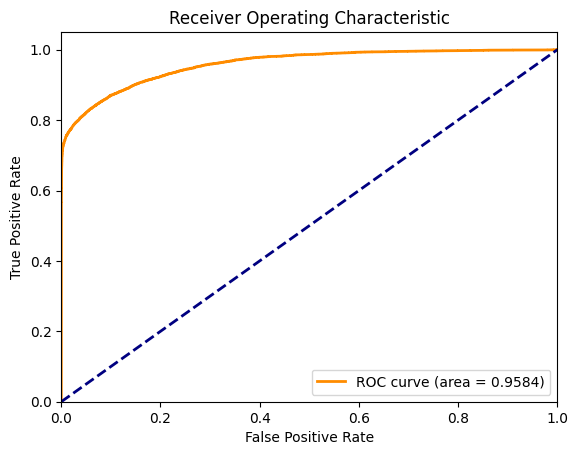

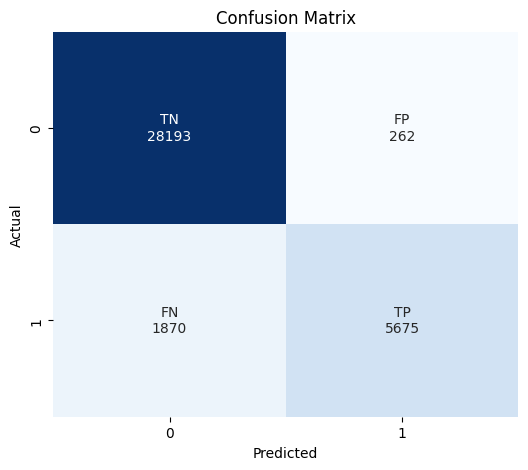

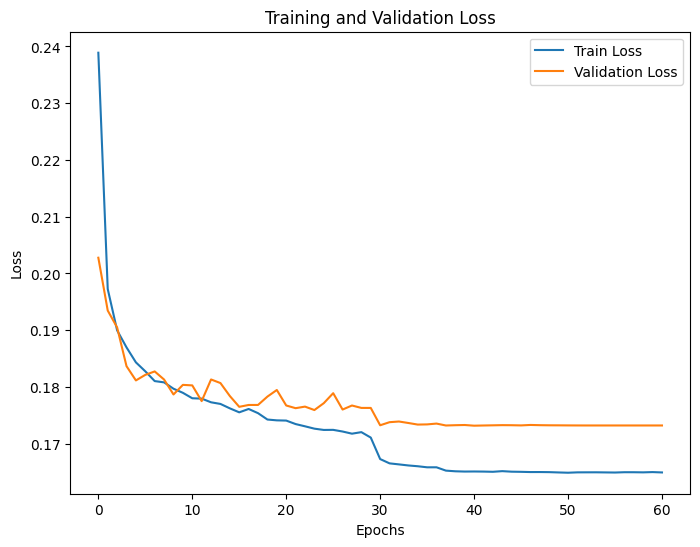

In [4]:
#plot roc curve 

fpr, tpr, _ = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_val, y_pred_binary)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#plot training and validation loss curves
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [5]:
"""

#Optuna hyperparameter tuning 

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print("using device:", device)
def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    first_layer = trial.suggest_categorical('first_layer', [64, 128, 256])
    second_layer = trial.suggest_categorical('second_layer', [32, 64, 128])
    third_layer = trial.suggest_categorical('third_layer', [16, 32, 64])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    model = ThreeLayerNN(input_size, first_layer, second_layer, third_layer).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

    train_dataset = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    best_loss = float('inf')
    counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch).squeeze()
                val_loss += criterion(outputs, y_batch).item()
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    return best_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)
print("Best val loss:", study.best_value)

"""

'\n\n#Optuna hyperparameter tuning \n\ndevice = torch.device(\'mps\' if torch.backends.mps.is_available() else \'cuda\' if torch.cuda.is_available() else \'cpu\')\nprint("using device:", device)\ndef objective(trial):\n    lr = trial.suggest_float(\'lr\', 1e-4, 1e-2, log=True)\n    first_layer = trial.suggest_categorical(\'first_layer\', [64, 128, 256])\n    second_layer = trial.suggest_categorical(\'second_layer\', [32, 64, 128])\n    third_layer = trial.suggest_categorical(\'third_layer\', [16, 32, 64])\n    batch_size = trial.suggest_categorical(\'batch_size\', [128, 256, 512])\n\n    model = ThreeLayerNN(input_size, first_layer, second_layer, third_layer).to(device)\n    optimizer = torch.optim.Adam(model.parameters(), lr=lr)\n    criterion = nn.BCELoss()\n    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)\n\n    train_dataset = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32))\n    tra

Best params from: {'lr': 0.0007511249842440639, 'first_layer': 256, 'second_layer': 32, 'third_layer': 32, 'batch_size': 256}

In [6]:
#Tuned parameters from optuna
params = {'lr': 0.0007511249842440639, 'first_layer': 256, 'second_layer': 32, 'third_layer': 32, 'batch_size': 256}

#save tuned parameters to a text file
with open('NN_CLASS_Tuned_Params.txt', 'w') as f:
    for key, value in params.items():
        f.write(f"{key}: {value}\n")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print("using device:", device)

#initiate tuned model
model_1_tuned = ThreeLayerNN(input_size, params['first_layer'], params['second_layer'], params['third_layer']).to(device)
lr = params['lr']
batch_size = params['batch_size']

criterion = nn.BCELoss()
optimizer = optim.AdamW(model_1_tuned.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

using device: mps


In [7]:
# train the model
train_dataset = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
val_loader = DataLoader(val_dataset, batch_size=batch_size)

best_loss = float('inf')
counter = 0
train_losses = []
val_losses = []
for epoch in range(epochs):
    model_1_tuned.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_1_tuned(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)

    model_1_tuned.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_1_tuned(X_batch).squeeze()
            val_loss += criterion(outputs, y_batch).item()
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_epoch_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    train_losses.append(avg_epoch_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0
        torch.save(model_1_tuned.state_dict(), 'NN_Class_1_Tuned.pth')
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model_1_tuned.load_state_dict(torch.load('NN_Class_1_Tuned.pth'))
torch.save(model_1_tuned.state_dict(), 'saved_models/NN_final_model_MI.pth')
print("Model saved to saved_models/NN_final_model_MI.pth")

with open('../Input_lists/NN_Mutual_Information_input_features.txt', 'w') as f:
    for feature in X_train.columns:
        f.write(f"{feature}\n")
print(f"Input features saved to Input_lists/NN_Mutual_Information_input_features.txt ({len(X_train.columns)} features)")

# Evaluate the model
model_1_tuned.eval()
with torch.no_grad():
    y_pred = model_1_tuned(torch.tensor(X_val.values, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    y_pred_binary = (y_pred > 0.5).astype(int)
    accuracy = accuracy_score(y_val, y_pred_binary)
    precision = precision_score(y_val, y_pred_binary)
    recall = recall_score(y_val, y_pred_binary)
    f1 = f1_score(y_val, y_pred_binary)
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")


Epoch 1/1000, Train Loss: 0.2461, Val Loss: 0.2068
Epoch 2/1000, Train Loss: 0.2017, Val Loss: 0.1962
Epoch 2/1000, Train Loss: 0.2017, Val Loss: 0.1962
Epoch 3/1000, Train Loss: 0.1933, Val Loss: 0.1894
Epoch 3/1000, Train Loss: 0.1933, Val Loss: 0.1894
Epoch 4/1000, Train Loss: 0.1887, Val Loss: 0.1880
Epoch 4/1000, Train Loss: 0.1887, Val Loss: 0.1880
Epoch 5/1000, Train Loss: 0.1853, Val Loss: 0.1863
Epoch 5/1000, Train Loss: 0.1853, Val Loss: 0.1863
Epoch 6/1000, Train Loss: 0.1840, Val Loss: 0.1825
Epoch 6/1000, Train Loss: 0.1840, Val Loss: 0.1825
Epoch 7/1000, Train Loss: 0.1829, Val Loss: 0.1818
Epoch 7/1000, Train Loss: 0.1829, Val Loss: 0.1818
Epoch 8/1000, Train Loss: 0.1819, Val Loss: 0.1826
Epoch 8/1000, Train Loss: 0.1819, Val Loss: 0.1826
Epoch 9/1000, Train Loss: 0.1812, Val Loss: 0.1817
Epoch 9/1000, Train Loss: 0.1812, Val Loss: 0.1817
Epoch 10/1000, Train Loss: 0.1804, Val Loss: 0.1806
Epoch 10/1000, Train Loss: 0.1804, Val Loss: 0.1806
Epoch 11/1000, Train Loss: 0.

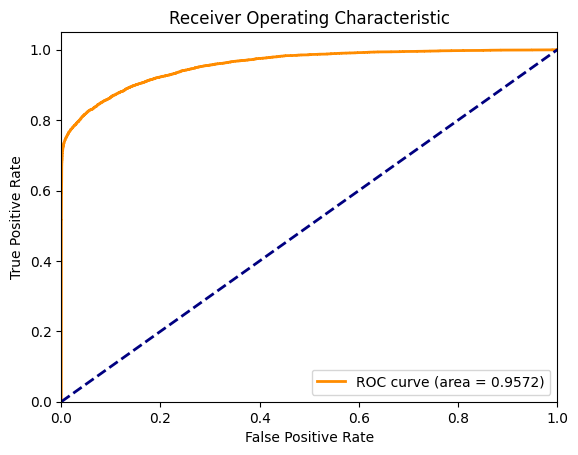

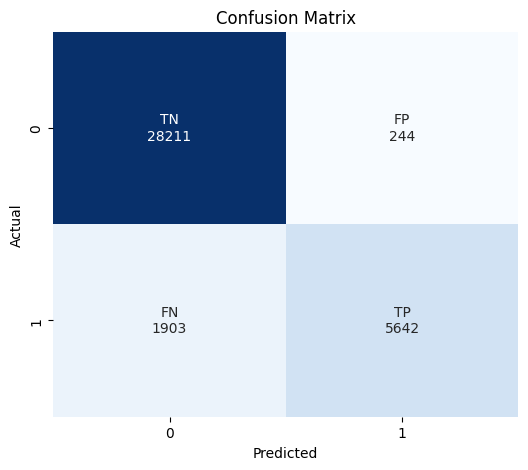

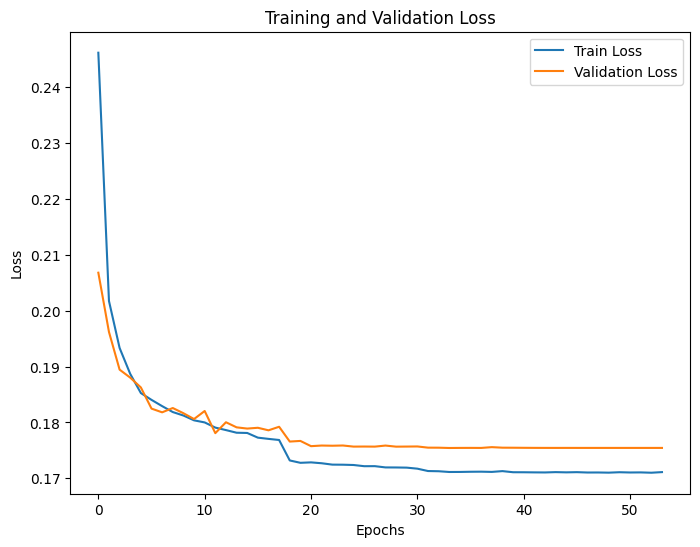

In [8]:
#plot roc curve 

fpr, tpr, _ = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_val, y_pred_binary)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#plot training and validation loss curves
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()